# 03 — 3-Way Six-Basis Comparison: Single Event vs All Composite vs CWB-Only

Compares PV-tendency decomposition using **three different orthogonal bases**,
all projecting the **same** single-event dq/dt (track 425):

| Label | Basis source | N events |
|-------|-------------|----------|
| **Single event** | Track 425 PV anomaly & gradients | 1 |
| **All composite** | All-event composite mean (~1260 onset) | 1260 |
| **CWB only** | CWB-only composite mean (cyclonic wave breaking) | 239 |

**Sections:**
1. PV anomaly + mask comparison (3×3 grid)
2. Six orthogonal basis modes side-by-side (6 rows × 3 cols)
3. Reconstruction components at dh=0 (3 separate 2×3 figures)
4. Lifecycle coefficient curves (β, αx, αy, γ₁, γ₂, σ)
5. αx and αy vs track-centre velocity overlay

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os, glob, json
from pathlib import Path

from pvtend import compute_orthogonal_basis, project_field, R_EARTH
from pvtend.plotting import plot_coefficient_curves, plot_field_2d
from pvtend.decomposition.projection import ADVECTION_TERMS
from pvtend.decomposition.smoothing import gaussian_smooth_nan
from pvtend.composite_builder import CompositeResult, CompositeConfig, build_composites

## 1  Configuration

In [2]:
# ── Composite (basis source) ──────────────────────────────────────────
PKL_PATH   = "/net/flood/data2/users/x_yan/tempest_extreme_4_basis/outputs/composite_blocking.pkl"
STAGE      = "onset"
LEVEL      = 200           # hPa level for reduce_2d (or "wavg")

# ── CWB-only composite ──────────────────────────────────────────────
CWB_IDS_JSON = "/net/flood/data2/users/x_yan/tempest_extreme_4_basis/research_questions/00_rwb_stage_clusters/track_ids/onset_CWB_only.json"
CWB_PKL_CACHE = "/net/flood/data2/users/x_yan/tempest_extreme_4_basis/outputs/composite_cwb_only.pkl"

# ── Single event (projection target) ────────────────────────────────
DATA_ROOT  = "/net/flood/data2/users/x_yan/composite_blocking_tempest"
TRACK_GLOB = "track_425_*"
TRACK_ID   = TRACK_GLOB.split("_")[1]   # "425"

# ── Shared settings ─────────────────────────────────────────────────
SMOOTH_DEG = 3.0
GRID_SP    = 1.5           # grid spacing in degrees
MASK_SPEC  = "< 0"         # composite mask (SI units)
MASK_SPEC_EVENT = "< -5e-7"  # single-event mask

# ── Labels & colours for the 3 basis types ──────────────────────────
COLORS = {"event": "C0", "all": "C1", "cwb": "C2"}

_lvl_str = f"{LEVEL} hPa" if isinstance(LEVEL, int) else "wavg"
print(f"Stage: {STAGE}   Level: {_lvl_str}")
print(f"Track: {TRACK_ID}   Smoothing: {SMOOTH_DEG}°   Grid: {GRID_SP}°")

Stage: onset   Level: 200 hPa
Track: 425   Smoothing: 3.0°   Grid: 1.5°


## 2  Load data: all-event composite, CWB-only composite, and single-event NPZ

In [3]:
# ── (a) Load all-event composite ─────────────────────────────────────
CR_all = CompositeResult.load(PKL_PATH)

LEVELS    = CR_all.levels
X_REL     = CR_all.x_rel
Y_REL     = CR_all.y_rel
DH_RANGE  = CR_all.available_dh(STAGE)
N_ALL     = CR_all.counts[STAGE][0]

x_rel = X_REL[0, :]
y_rel = Y_REL[:, 0]

def _cm_all(dh, field_name):
    '''All-event composite-mean 2-D field at the configured LEVEL.'''
    key = field_name if field_name.endswith("_3d") else field_name + "_3d"
    return CR_all.reduce_2d(key, STAGE, dh, level_mode=LEVEL)

print(f"All-event composite: dh = {DH_RANGE[0]}…{DH_RANGE[-1]}  ({len(DH_RANGE)} steps),  N ≈ {N_ALL}")

# ── (b) Build or load CWB-only composite ────────────────────────────
if os.path.isfile(CWB_PKL_CACHE):
    print(f"\nLoading cached CWB-only PKL: {CWB_PKL_CACHE}")
    CR_cwb = CompositeResult.load(CWB_PKL_CACHE)
else:
    print(f"\nBuilding CWB-only composite from NPZ (first run, may take a few minutes)...")
    with open(CWB_IDS_JSON) as f:
        cwb_ids = frozenset(json.load(f))
    print(f"  CWB track IDs loaded: {len(cwb_ids)} tracks")

    class _MinimalRWB:
        def __init__(self, vt):
            self._vt = vt
        @property
        def variant_trackset(self):
            return self._vt

    cfg = CompositeConfig(npz_dir=Path(DATA_ROOT), stages=[STAGE])
    CR_cwb = build_composites(cfg, _MinimalRWB({"CWB_only": cwb_ids}))
    CR_cwb.save(CWB_PKL_CACHE)

N_CWB = CR_cwb.counts_v.get("CWB_only", {}).get(STAGE, {}).get(0, 0)
DH_RANGE_CWB = CR_cwb.available_dh(STAGE, variant="CWB_only")

def _cm_cwb(dh, field_name):
    '''CWB-only composite-mean 2-D field at the configured LEVEL.'''
    key = field_name if field_name.endswith("_3d") else field_name + "_3d"
    return CR_cwb.reduce_2d(key, STAGE, dh, variant="CWB_only", level_mode=LEVEL)

print(f"CWB-only composite: N ≈ {N_CWB}")

# ── (c) Load single-event dh=0 ──────────────────────────────────────
d0 = dict(np.load(f"{DATA_ROOT}/{STAGE}/dh=+0/{TRACK_GLOB.replace('*','2000011120_dh+0')}.npz"))
print(f"\nSingle event: track {TRACK_ID},  patch shape: {d0['pv_anom'].shape}")

# ── Labels ──────────────────────────────────────────────────────────
LABELS = {
    "event": f"Single event (Track {TRACK_ID})",
    "all":   f"All-event composite (N≈{N_ALL})",
    "cwb":   f"CWB-only composite (N≈{N_CWB})",
}

All-event composite: dh = -13…12  (26 steps),  N ≈ 1260

Building CWB-only composite from NPZ (first run, may take a few minutes)...
  CWB track IDs loaded: 239 tracks

[pass2] Accumulating composites ...
[onset] dh=-13: total=1260 loaded=1260
[onset] dh=-12: total=1260 loaded=1260
[onset] dh=-11: total=1260 loaded=1260
[onset] dh=-10: total=1260 loaded=1260
[onset] dh=-9: total=1260 loaded=1260
[onset] dh=-8: total=1260 loaded=1260
[onset] dh=-7: total=1260 loaded=1260
[onset] dh=-6: total=1260 loaded=1260
[onset] dh=-5: total=1260 loaded=1260
[onset] dh=-4: total=1260 loaded=1260
[onset] dh=-3: total=1260 loaded=1260
[onset] dh=-2: total=1260 loaded=1260
[onset] dh=-1: total=1260 loaded=1260
[onset] dh=+0: total=1260 loaded=1260
[onset] dh=+1: total=1260 loaded=1260
[onset] dh=+2: total=1260 loaded=1260
[onset] dh=+3: total=1260 loaded=1260
[onset] dh=+4: total=1260 loaded=1260
[onset] dh=+5: total=1260 loaded=1260
[onset] dh=+6: total=1260 loaded=1260
[onset] dh=+7: total=1260 loade

## 3  Build three orthogonal bases from PV anomaly (dh = 0)

In [4]:
smooth = lambda f: gaussian_smooth_nan(f, smoothing_deg=SMOOTH_DEG, grid_spacing=GRID_SP)

# ── Single-event basis ──────────────────────────────────────────────
basis_ev = compute_orthogonal_basis(
    pv_anom=d0["pv_anom"], pv_dx=d0["pv_dx"], pv_dy=d0["pv_dy"],
    x_rel=x_rel, y_rel=y_rel, mask=MASK_SPEC_EVENT,
    apply_smoothing=True, smoothing_deg=SMOOTH_DEG, grid_spacing=GRID_SP,
)
print("Single-event basis norms:", {k: f"{v:.4e}" for k, v in basis_ev.norms.items()})

# ── All-event composite basis ───────────────────────────────────────
basis_all = compute_orthogonal_basis(
    pv_anom=_cm_all(0, "pv_anom"), pv_dx=_cm_all(0, "pv_dx"), pv_dy=_cm_all(0, "pv_dy"),
    x_rel=x_rel, y_rel=y_rel, mask=MASK_SPEC,
    apply_smoothing=True, smoothing_deg=SMOOTH_DEG, grid_spacing=GRID_SP,
)
print("All-composite basis norms:", {k: f"{v:.4e}" for k, v in basis_all.norms.items()})

# ── CWB-only composite basis ───────────────────────────────────────
basis_cwb = compute_orthogonal_basis(
    pv_anom=_cm_cwb(0, "pv_anom"), pv_dx=_cm_cwb(0, "pv_dx"), pv_dy=_cm_cwb(0, "pv_dy"),
    x_rel=x_rel, y_rel=y_rel, mask=MASK_SPEC,
    apply_smoothing=True, smoothing_deg=SMOOTH_DEG, grid_spacing=GRID_SP,
)
print("CWB-only basis norms:", {k: f"{v:.4e}" for k, v in basis_cwb.norms.items()})

bases = {"event": basis_ev, "all": basis_all, "cwb": basis_cwb}

Single-event basis norms: {'beta': '2.4847e+03', 'ax': '6.9257e+03', 'ay': '4.2084e+03', 'gamma': '2.1591e+04'}
All-composite basis norms: {'beta': '7.2907e+02', 'ax': '1.0891e+03', 'ay': '8.6239e+02', 'gamma': '8.0318e+02'}
CWB-only basis norms: {'beta': '5.6915e+02', 'ax': '1.1459e+03', 'ay': '7.3028e+02', 'gamma': '1.0486e+03'}


## 4  Section 1 — PV anomaly at dh=−2, −1, 0 with basis mask contour

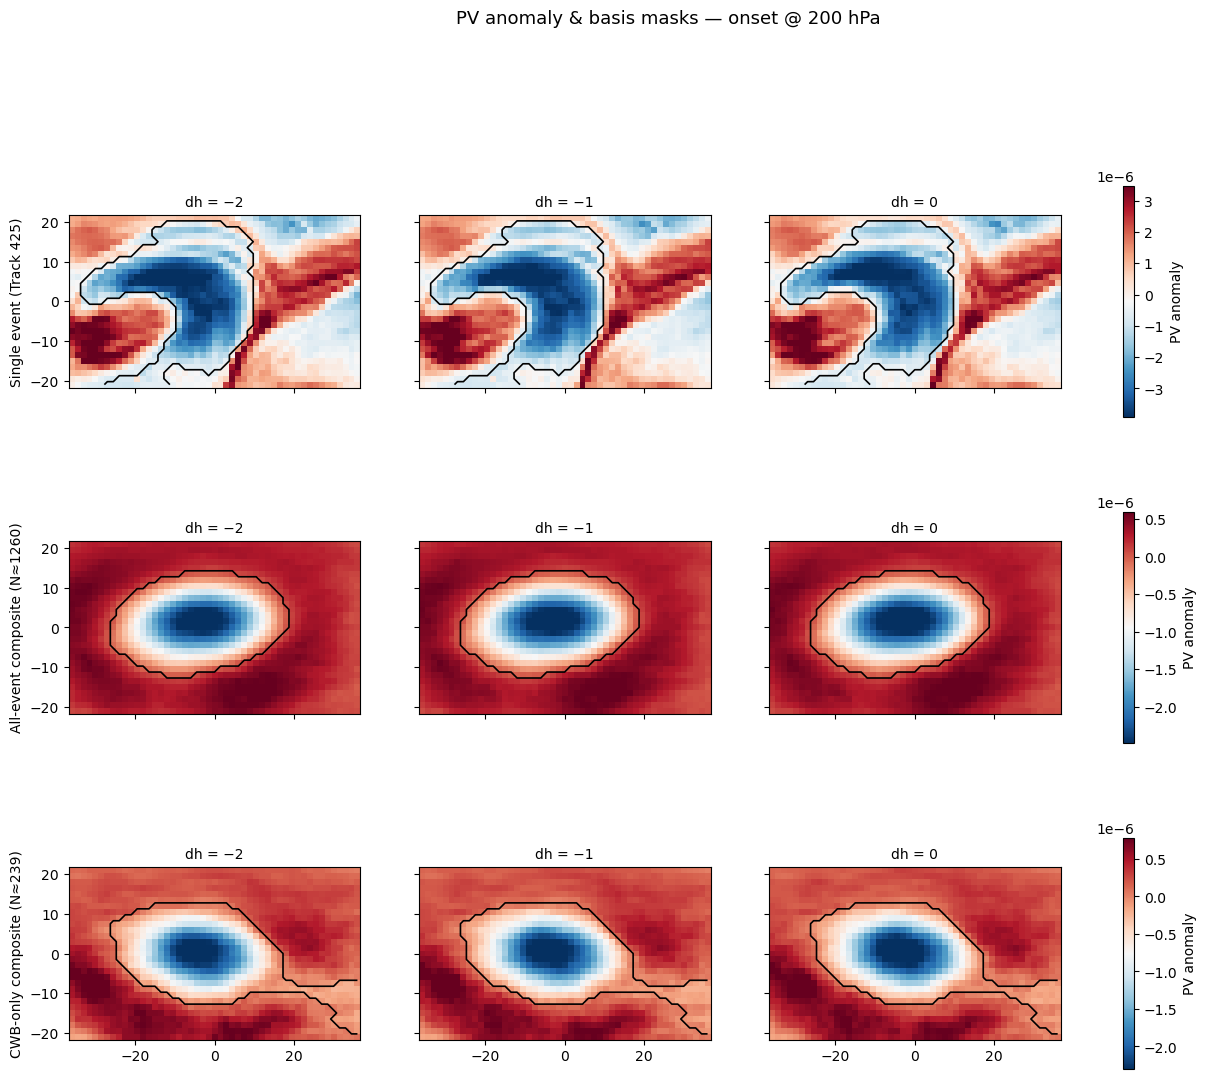

In [12]:
# ── Load single-event fields at dh = -2, -1, 0 ──────────────────────
event_fields = {}
for dh_ev in [-2, -1, 0]:
    sign = "+" if dh_ev >= 0 else ""
    pat = f"{DATA_ROOT}/{STAGE}/dh={sign}{dh_ev}/track_{TRACK_ID}_*_dh{sign}{dh_ev}.npz"
    f = sorted(glob.glob(pat))
    if f:
        event_fields[dh_ev] = dict(np.load(f[0]))

fig, axes = plt.subplots(3, 3, figsize=(16, 12), sharex=True, sharey=True)
dh_labels = ["dh = −2", "dh = −1", "dh = 0"]

# ── Row 0: single event ─────────────────────────────────────────────
vmin_e, vmax_e = np.nanpercentile(d0["pv_anom"], [2, 98])
for ax, dh, ttl in zip(axes[0], [-2, -1, 0], dh_labels):
    fld = event_fields.get(dh, {}).get("pv_anom", np.full_like(d0["pv_anom"], np.nan))
    im0 = ax.pcolormesh(X_REL, Y_REL, fld, cmap="RdBu_r",
                        vmin=vmin_e, vmax=vmax_e, shading="auto")
    ax.contour(X_REL, Y_REL, basis_ev.mask.astype(float), levels=[0.5],
               colors="k", linewidths=1.2)
    ax.set_title(ttl, fontsize=10)
    ax.set_aspect("equal")
axes[0, 0].set_ylabel(LABELS["event"], fontsize=10)
fig.colorbar(im0, ax=axes[0, :].tolist(), label="PV anomaly", shrink=0.85)

# ── Row 1: all-event composite ──────────────────────────────────────
vmin_a, vmax_a = np.nanpercentile(_cm_all(0, "pv_anom"), [2, 98])
for ax, dh, ttl in zip(axes[1], [-2, -1, 0], dh_labels):
    fld = _cm_all(dh, "pv_anom")
    im1 = ax.pcolormesh(X_REL, Y_REL, fld, cmap="RdBu_r",
                        vmin=vmin_a, vmax=vmax_a, shading="auto")
    ax.contour(X_REL, Y_REL, basis_all.mask.astype(float), levels=[0.5],
               colors="k", linewidths=1.2)
    ax.set_title(ttl, fontsize=10)
    ax.set_aspect("equal")
axes[1, 0].set_ylabel(LABELS["all"], fontsize=10)
fig.colorbar(im1, ax=axes[1, :].tolist(), label="PV anomaly", shrink=0.85)

# ── Row 2: CWB-only composite ───────────────────────────────────────
vmin_w, vmax_w = np.nanpercentile(_cm_cwb(0, "pv_anom"), [2, 98])
for ax, dh, ttl in zip(axes[2], [-2, -1, 0], dh_labels):
    fld = _cm_cwb(dh, "pv_anom")
    im2 = ax.pcolormesh(X_REL, Y_REL, fld, cmap="RdBu_r",
                        vmin=vmin_w, vmax=vmax_w, shading="auto")
    ax.contour(X_REL, Y_REL, basis_cwb.mask.astype(float), levels=[0.5],
               colors="k", linewidths=1.2)
    ax.set_title(ttl, fontsize=10)
    ax.set_aspect("equal")
axes[2, 0].set_ylabel(LABELS["cwb"], fontsize=10)
fig.colorbar(im2, ax=axes[2, :].tolist(), label="PV anomaly", shrink=0.85)

fig.suptitle(f"PV anomaly & basis masks — {STAGE} @ {_lvl_str}", fontsize=13, y=1.01)
# plt.tight_layout()
plt.show()

## 5  Section 2 — Six orthogonal basis modes (6 rows × 3 columns)

In [ ]:
phi_names = [r"$\Phi_1$ (intensity)", r"$\Phi_2$ (zonal grad.)",
             r"$\Phi_3$ (merid. grad.)", r"$\Phi_4$ (shear def.)",
             r"$\Phi_5$ (strain def.)", r"$\Phi_6$ (Laplacian)"]
phi_attrs = ["phi_int", "phi_dx", "phi_dy", "phi_def", "phi_strain", "phi_lap"]
basis_keys = ["event", "all", "cwb"]

fig, axes = plt.subplots(6, 3, figsize=(15, 16), sharex=True, sharey=True)

for row, (attr, phi_label) in enumerate(zip(phi_attrs, phi_names)):
    # Shared colorscale per row across the 3 basis types
    all_vals = np.concatenate([np.ravel(getattr(bases[k], attr)) for k in basis_keys])
    vmax = np.nanpercentile(np.abs(all_vals), 98)
    levels = np.linspace(-vmax, vmax, 21)

    for col, bkey in enumerate(basis_keys):
        ax = axes[row, col]
        b = bases[bkey]
        fld = getattr(b, attr)
        cf = ax.contourf(x_rel, y_rel, fld, levels=levels, cmap="coolwarm", extend="both")
        ax.contour(x_rel, y_rel, b.mask.astype(float), levels=[0.5],
                   colors="k", linewidths=0.8)
        ax.set_aspect("equal")

        if row == 0:
            ax.set_title(LABELS[bkey], fontsize=10, fontweight="bold")
        if col == 0:
            ax.set_ylabel(phi_label, fontsize=11)

    fig.colorbar(cf, ax=axes[row, :].tolist(), shrink=0.8, pad=0.02)

fig.suptitle(f"Orthogonal basis comparison — {STAGE} dh=0 @ {_lvl_str}", fontsize=13, y=1.01)
# plt.tight_layout()
plt.show()

## 6  Section 3 — Reconstruction at dh=0: components + quality

For each basis, top row shows: intensification (β·Φ₁), propagation (−αx·Φ₂ − αy·Φ₃), deformation (γ·Φ₄).
Bottom row: original dq/dt, reconstructed, residual.

In [ ]:
# ── Project track 425 dq/dt onto all 3 bases ────────────────────────
pv_dt = d0["pv_anom_dt"] + d0["pv_bar_dt"]
pv_dt_smooth = smooth(pv_dt)

projs = {}
for bkey in basis_keys:
    projs[bkey] = project_field(pv_dt_smooth, bases[bkey])
    p = projs[bkey]
    print(f"\n{LABELS[bkey]}:")
    print(f"  β  = {p['beta']:.3e} s⁻¹,  αx = {p['ax']:.2f} m/s,  αy = {p['ay']:.2f} m/s,  γ₁ = {p['gamma1']:.3e},  γ₂ = {p['gamma2']:.3e},  σ = {p['sigma']:.3e} m² s⁻¹")
    mask_ok = np.isfinite(pv_dt_smooth) & np.isfinite(p["recon"])
    corr = np.corrcoef(pv_dt_smooth[mask_ok], p["recon"][mask_ok])[0, 1]
    print(f"  RMSE / max|dq/dt| = {p['rmse'] / (np.nanmax(np.abs(pv_dt_smooth)) + 1e-30):.3f},  Corr = {corr:.4f}")

In [ ]:
for bkey in basis_keys:
    b = bases[bkey]
    p = projs[bkey]

    # ── Component fields ────────────────────────────────────────────
    int_comp  = p["beta_raw"]  * b.phi_int
    prp_comp  = -p["ax_raw"]   * b.phi_dx  + (-p["ay_raw"] * b.phi_dy)
    def1_comp  = -p["gamma1_raw"] * b.phi_def
    def2_comp  = -p["gamma2_raw"] * b.phi_strain
    lap_comp   = p["sigma_raw"]  * b.phi_lap
    recon     = p["recon"]
    resid     = p["resid"]

    # ── Shared colour limits ────────────────────────────────────────
    vmax_top = max(np.nanpercentile(np.abs(int_comp), 97),
                   np.nanpercentile(np.abs(prp_comp), 97),
                   np.nanpercentile(np.abs(def_comp), 97))
    vmax_bot = np.nanpercentile(np.abs(pv_dt_smooth), 99)
    lev_top = np.linspace(-vmax_top, vmax_top, 20)
    lev_bot = np.linspace(-vmax_bot, vmax_bot, 20)

    fig, axes = plt.subplots(2, 3, figsize=(17, 9))

    # ── Top row: component maps ─────────────────────────────────────
    for i, (fld, ttl) in enumerate([
        (int_comp, r"Intensification ($\beta \cdot \Phi_1$)"),
        (prp_comp, r"Propagation ($-\alpha_x \Phi_2 - \alpha_y \Phi_3$)"),
        (def1_comp, r"Shear def. ($-\gamma_1 \cdot \Phi_4$)"),
        (def2_comp, r"Strain def. ($-\gamma_2 \cdot \Phi_5$)"),
        (lap_comp,  r"Laplacian ($\sigma \cdot \Phi_6$)"),
    ]):
        ax = axes[0, i]
        cf = ax.contourf(x_rel, y_rel, fld, levels=lev_top, cmap="coolwarm", extend="both")
        ax.contour(x_rel, y_rel, b.mask.astype(float), levels=[0.5], colors="k", linewidths=0.8)
        ax.set_title(ttl, fontsize=9)
        ax.set_aspect("equal")
    fig.colorbar(cf, ax=axes[0, :].tolist(), shrink=0.8, label="PVU / s")

    # ── Bottom row: original, reconstructed, residual ───────────────
    for i, (fld, ttl) in enumerate([
        (pv_dt_smooth, "Original dq/dt (smoothed)"),
        (recon,        r"Reconstructed (6-basis)"),
        (resid,        "Residual"),
    ]):
        ax = axes[1, i]
        cf2 = ax.contourf(x_rel, y_rel, fld, levels=lev_bot, cmap="coolwarm", extend="both")
        ax.contour(x_rel, y_rel, b.mask.astype(float), levels=[0.5], colors="k", linewidths=0.8)
        ax.set_title(ttl, fontsize=9)
        ax.set_aspect("equal")
    fig.colorbar(cf2, ax=axes[1, :].tolist(), shrink=0.8, label="PVU / s")

    mask_ok = np.isfinite(pv_dt_smooth) & np.isfinite(recon)
    corr = np.corrcoef(pv_dt_smooth[mask_ok], recon[mask_ok])[0, 1]
    subtitle = (f"β={p['beta']:.2e} s⁻¹,  αx={p['ax']:.2f} m/s,  "
                f"αy={p['ay']:.2f} m/s,  γ₁={p['gamma1']:.2e},  γ₂={p['gamma2']:.2e},  σ={p['sigma']:.2e}  |  Corr={corr:.3f}")
    fig.suptitle(f"{LABELS[bkey]} — dh=0 ({_lvl_str})\n{subtitle}", fontsize=12, y=1.03)
    # plt.tight_layout()
    plt.show()

## 7  Section 4 — Lifecycle coefficient curves (3-way comparison)

In [ ]:
dh_values = list(range(-13, 13))
coefs_3way = {bkey: {k: [] for k in ["beta", "ax", "ay", "gamma1", "gamma2", "sigma"]} for bkey in basis_keys}

for dh in dh_values:
    sign = "+" if dh >= 0 else ""

    # ── Load single-event NPZ at this dh ────────────────────────────
    pattern = f"{DATA_ROOT}/{STAGE}/dh={sign}{dh}/track_{TRACK_ID}_*_dh{sign}{dh}.npz"
    files = sorted(glob.glob(pattern))
    if not files:
        for bkey in basis_keys:
            for k in coefs_3way[bkey]:
                coefs_3way[bkey][k].append(np.nan)
        continue
    dd = dict(np.load(files[0]))
    pv_dt_s = smooth(dd["pv_anom_dt"] + dd["pv_bar_dt"])

    # ── Single-event basis at this dh ───────────────────────────────
    b_ev = compute_orthogonal_basis(
        dd["pv_anom"], dd["pv_dx"], dd["pv_dy"],
        x_rel, y_rel, mask=MASK_SPEC_EVENT,
        apply_smoothing=True, smoothing_deg=SMOOTH_DEG, grid_spacing=GRID_SP,
    )
    p_ev = project_field(pv_dt_s, b_ev)
    for k in coefs_3way["event"]:
        coefs_3way["event"][k].append(p_ev[k])

    # ── All-composite basis at this dh ──────────────────────────────
    if dh in DH_RANGE:
        b_all = compute_orthogonal_basis(
            _cm_all(dh, "pv_anom"), _cm_all(dh, "pv_dx"), _cm_all(dh, "pv_dy"),
            x_rel, y_rel, mask=MASK_SPEC,
            apply_smoothing=True, smoothing_deg=SMOOTH_DEG, grid_spacing=GRID_SP,
        )
        p_all = project_field(pv_dt_s, b_all)
        for k in coefs_3way["all"]:
            coefs_3way["all"][k].append(p_all[k])
    else:
        for k in coefs_3way["all"]:
            coefs_3way["all"][k].append(np.nan)

    # ── CWB-only basis at this dh ──────────────────────────────────
    if dh in DH_RANGE_CWB:
        b_cwb = compute_orthogonal_basis(
            _cm_cwb(dh, "pv_anom"), _cm_cwb(dh, "pv_dx"), _cm_cwb(dh, "pv_dy"),
            x_rel, y_rel, mask=MASK_SPEC,
            apply_smoothing=True, smoothing_deg=SMOOTH_DEG, grid_spacing=GRID_SP,
        )
        p_cwb = project_field(pv_dt_s, b_cwb)
        for k in coefs_3way["cwb"]:
            coefs_3way["cwb"][k].append(p_cwb[k])
    else:
        for k in coefs_3way["cwb"]:
            coefs_3way["cwb"][k].append(np.nan)

    print(f"dh={sign}{dh:>3d}  β_ev={p_ev['beta']:.3e}  β_all={coefs_3way['all']['beta'][-1]:.3e}  β_cwb={coefs_3way['cwb']['beta'][-1]:.3e}")

for bkey in basis_keys:
    for k in coefs_3way[bkey]:
        coefs_3way[bkey][k] = np.array(coefs_3way[bkey][k])

dh_arr = np.array(dh_values)
print(f"\nDone — {len(dh_values)} steps × 3 bases")

In [ ]:
coef_info = [
    ("beta",  r"$\beta$ (intensification)",      r"s$^{-1}$"),
    ("ax",    r"$\alpha_x$ (zonal propagation)",  "m / s"),
    ("ay",    r"$\alpha_y$ (merid. propagation)", "m / s"),
    ("gamma1", r"$\gamma_1$ (shear def.)",        r"m$^2$ s$^{-1}$"),
    ("gamma2", r"$\gamma_2$ (strain def.)",       r"m$^2$ s$^{-1}$"),
    ("sigma",  r"$\sigma$ (Laplacian)",           r"m$^2$ s$^{-1}$"),
]

fig, axes = plt.subplots(3, 2, figsize=(14, 8), sharex=True)

for i, (key, title, unit) in enumerate(coef_info):
    ax = axes.flat[i]
    for bkey in basis_keys:
        ax.plot(dh_arr, coefs_3way[bkey][key], f"{COLORS[bkey]}-o", ms=3,
                lw=1.8, label=LABELS[bkey])
    ax.axhline(0, color="gray", lw=0.5, ls=":")
    ax.axvline(0, color="gray", lw=0.5, ls=":")
    ax.set_title(title)
    ax.set_ylabel(unit)

axes[1, 0].set_xlabel("Hours relative to onset")
axes[1, 1].set_xlabel("Hours relative to onset")
axes[0, 0].legend(fontsize=8, loc="best")

fig.suptitle(f"Track {TRACK_ID} — Lifecycle coefficients, 3-way basis comparison ({STAGE}, {_lvl_str})",
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

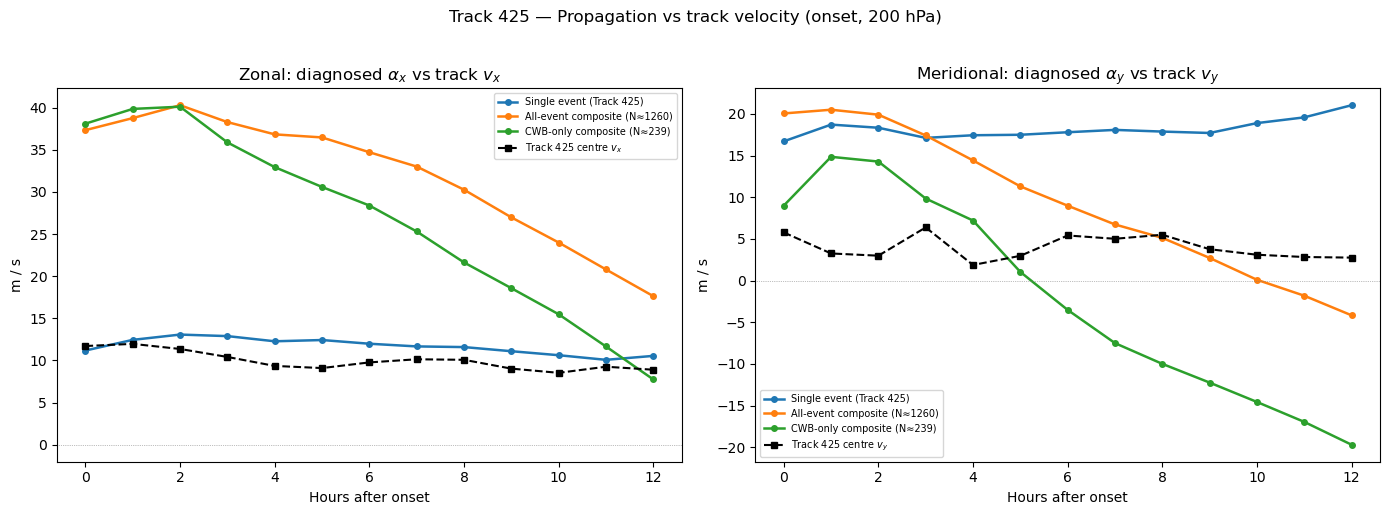

In [18]:
# ── Section 5: αx and αy vs track-centre velocity ───────────────────
from datetime import datetime, timedelta

# ── 1. Parse track centres from blockstats ───────────────────────────
BLOCKSTATS = "/net/flood/data2/users/x_yan/tracking_tmpp/ERA5_blockstats.txt"
track_rows = []
with open(BLOCKSTATS) as fh:
    for line in fh:
        parts = line.strip().split("\t")
        if parts[0].strip() == TRACK_ID:
            track_rows.append(parts)

_ts_list, _lat_list, _lon_list = [], [], []
for row in track_rows:
    ts_str = row[2].strip().strip('"')
    _ts_list.append(datetime.strptime(ts_str, "%Y-%m-%d %H:%M:%S"))
    _lat_list.append(float(row[3].strip()))
    _lon_list.append(float(row[4].strip()))

ts_arr = np.array(_ts_list)
lat_arr = np.array(_lat_list)
lon_arr = np.array(_lon_list)

# ── 2. Compute track velocity (m/s) via centred differences ─────────
cos_lat = np.cos(np.radians(lat_arr))
dlat = np.gradient(lat_arr)
dlon = np.gradient(lon_arr)
vx_track = dlon * (np.pi / 180.0) * R_EARTH * cos_lat / 3600.0
vy_track = dlat * (np.pi / 180.0) * R_EARTH / 3600.0

# ── 3. Map dh → track velocity ──────────────────────────────────────
onset_ts = datetime.strptime(str(d0["ts"]), "%Y-%m-%d %H:%M:%S")
track_vx_at_dh = np.full_like(dh_arr, np.nan, dtype=float)
track_vy_at_dh = np.full_like(dh_arr, np.nan, dtype=float)
for i, dh in enumerate(dh_arr):
    target_ts = onset_ts + timedelta(hours=int(dh))
    matches = np.where(ts_arr == target_ts)[0]
    if len(matches) == 1:
        idx = matches[0]
        track_vx_at_dh[i] = vx_track[idx]
        track_vy_at_dh[i] = vy_track[idx]

# ── 4. Two panels: αx & αy vs track velocity (dh ≥ 0 only) ─────────
mask_pos = dh_arr >= 0
dh_pos = dh_arr[mask_pos]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Panel A: αx
for bkey in basis_keys:
    ax1.plot(dh_pos, coefs_3way[bkey]["ax"][mask_pos], f"{COLORS[bkey]}-o", ms=4,
             lw=1.8, label=LABELS[bkey])
ax1.plot(dh_pos, track_vx_at_dh[mask_pos], "k--s", ms=4, lw=1.5,
         label=f"Track {TRACK_ID} centre $v_x$")
ax1.axhline(0, color="grey", lw=0.5, ls=":")
ax1.set_xlabel("Hours after onset")
ax1.set_ylabel("m / s")
ax1.set_title(r"Zonal: diagnosed $\alpha_x$ vs track $v_x$")
ax1.legend(fontsize=7, loc="best")

# Panel B: αy
for bkey in basis_keys:
    ax2.plot(dh_pos, coefs_3way[bkey]["ay"][mask_pos], f"{COLORS[bkey]}-o", ms=4,
             lw=1.8, label=LABELS[bkey])
ax2.plot(dh_pos, track_vy_at_dh[mask_pos], "k--s", ms=4, lw=1.5,
         label=f"Track {TRACK_ID} centre $v_y$")
ax2.axhline(0, color="grey", lw=0.5, ls=":")
ax2.set_xlabel("Hours after onset")
ax2.set_ylabel("m / s")
ax2.set_title(r"Meridional: diagnosed $\alpha_y$ vs track $v_y$")
ax2.legend(fontsize=7, loc="best")

fig.suptitle(f"Track {TRACK_ID} — Propagation vs track velocity ({STAGE}, {_lvl_str})",
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()